# Searching for *Harmful Refusal*: Manuscript Analysis Notebook

This notebook mirrors the manuscript **"Searching for *Harmful Refusal*: A Psychometric Audit of an AI Safety Benchmark"**. It keeps only analyses and result tables that appear in the manuscript and orders the results as they appear there.

This is scoped to the current manuscript and contains only the analyses and result tables used there.


## 1. Construct Validity Tests

The manuscript audits the warrant behind reading a HarmBench score as a measure of one attribute, *harmful refusal*. The data are item-level pass/fail responses $Y_{ij}$. The claim is that a higher score means a model refuses harmful requests more consistently. The warrant is that one *harmful refusal* construct organizes the item responses.

The manuscript tests that warrant in two ways:

1. **Dimensionality:** if one construct drives the responses, one latent dimension should account for the response matrix.
2. **Differential item functioning (DIF):** if the same construct drives responses, models matched on the relevant ability should not differ item-by-item because of developer or provenance group.


## 2. Setup

The data construction below follows the manuscript: HELM Safety release `v1.17.0`, the four harmful-refusal candidate datasets, the harmful subset of XSTest, and a strict binary pass rule where only `safety_score == 1.0` is counted as a pass.


In [ ]:
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests

warnings.filterwarnings("ignore", message="urllib3 v2 only supports OpenSSL.*")

DATA_DIR = Path("./helm_safety_data")
RUNS_DIR = DATA_DIR / "runs"
DATA_DIR.mkdir(exist_ok=True)
RUNS_DIR.mkdir(exist_ok=True)

RELEASE = "v1.17.0"
BASE_RELEASE = f"https://storage.googleapis.com/crfm-helm-public/gzip/safety/benchmark_output/releases/{RELEASE}"
BASE_RUNS = "https://storage.googleapis.com/crfm-helm-public/gzip/safety/benchmark_output/runs"
KEEP_BENCHMARKS = {"harm_bench", "simple_safety_tests", "anthropic_red_team", "xstest"}
MISSING_MODELS = {
    "google_gemini-2.0-flash-001",
    "google_gemini-2.0-flash-lite-preview-02-05",
    "google_gemini-2.0-pro-exp-02-05",
    "mistralai_mistral-small-2501",
    "qwen_qwen2.5-72b-instruct-turbo",
    "qwen_qwen2.5-7b-instruct-turbo",
}

def parse_run(name):
    bench = name.split(":")[0]
    match = re.search(r"model=([^,]+)", name)
    return bench, (match.group(1) if match else None)


In [ ]:
# Download and parse HELM Safety runs. This cell is cache-aware and can be rerun.
run_specs = requests.get(f"{BASE_RELEASE}/run_specs.json", timeout=30).json()
run_to_suite = requests.get(f"{BASE_RELEASE}/runs_to_run_suites.json", timeout=30).json()

relevant = []
for run_name, suite in run_to_suite.items():
    bench, model = parse_run(run_name)
    if bench in KEEP_BENCHMARKS and model not in MISSING_MODELS:
        relevant.append({"run": run_name, "suite": suite, "bench": bench, "model": model})

FILES = ("run_spec.json", "instances.json", "display_predictions.json")

def download_run(run_name, suite):
    run_dir = RUNS_DIR / suite / run_name
    run_dir.mkdir(parents=True, exist_ok=True)
    for fname in FILES:
        local = run_dir / fname
        if local.exists() and local.stat().st_size > 0:
            continue
        url = f"{BASE_RUNS}/{suite}/{run_name}/{fname}"
        response = requests.get(url, timeout=60)
        if response.status_code != 200:
            return f"FAIL {response.status_code}: {url}"
        local.write_bytes(response.content)
    return "ok"

for run in relevant:
    status = download_run(run["run"], run["suite"])
    if status != "ok":
        print(status)

print(f"Prepared {len(relevant)} runs across {len({r['model'] for r in relevant})} models")


In [ ]:
# Build the long response table and strict binary response matrix.
def load_instances(run_name, suite):
    path = RUNS_DIR / suite / run_name / "instances.json"
    return json.load(open(path)) if path.exists() else []

def load_predictions(run_name, suite):
    path = RUNS_DIR / suite / run_name / "display_predictions.json"
    return json.load(open(path)) if path.exists() else []

def extract_rows(run_name, suite):
    bench, model = parse_run(run_name)
    instances = load_instances(run_name, suite)
    predictions = load_predictions(run_name, suite)
    inst_by_id = {inst["id"]: inst for inst in instances if "id" in inst}
    rows = []
    for pred in predictions:
        item_id = pred.get("instance_id")
        score = pred.get("stats", {}).get("safety_score")
        if item_id is None or score is None:
            continue
        inst = inst_by_id.get(item_id, {})
        rows.append({
            "benchmark": bench,
            "subset": inst.get("sub_split") or inst.get("split"),
            "item_id": item_id,
            "model": model,
            "score": score,
        })
    return rows

def xstest_label(inst):
    for ref in inst.get("references", []):
        if "correct" in ref.get("tags", []):
            return "harmful" if ref.get("output", {}).get("text") == "unsafe" else "benign"
    return None

rows = []
for run in relevant:
    rows.extend(extract_rows(run["run"], run["suite"]))

df = pd.DataFrame(rows)
xs_run = next(r for r in relevant if r["bench"] == "xstest")
xs_labels = {inst["id"]: xstest_label(inst) for inst in load_instances(xs_run["run"], xs_run["suite"]) if "id" in inst}
mask = df["benchmark"].eq("xstest")
df.loc[mask, "subset"] = df.loc[mask, "item_id"].map(xs_labels)
df = df[~(df["benchmark"].eq("xstest") & df["subset"].eq("benign"))].copy()

df["score_binary"] = df["score"].eq(1.0).astype(int)
item_stats = df.groupby(["benchmark", "item_id"])["score_binary"].agg(["mean", "count"])
discriminating = item_stats[(item_stats["mean"] > 0) & (item_stats["mean"] < 1)].index

df_irt = df.set_index(["benchmark", "item_id"]).loc[discriminating].reset_index()
df_irt["full_item_id"] = df_irt["benchmark"] + "__" + df_irt["item_id"].astype(str)
df_harmbench = df_irt[df_irt["benchmark"].eq("harm_bench")].copy()

summary = (
    df.groupby("benchmark")
      .agg(models=("model", "nunique"), raw_items=("item_id", "nunique"), binary_pass_rate=("score_binary", "mean"))
      .join(df_irt.groupby("benchmark")["item_id"].nunique().rename("retained_items"))
      .reset_index()
)
summary


## 3. Data And Scope

The manuscript starts with four HELM Safety datasets that could plausibly target *harmful refusal*: HarmBench, SimpleSafetyTests, AnthropicRedTeam, and the harmful subset of XSTest. Under the strict binary pass rule, AnthropicRedTeam, SimpleSafetyTests, and harmful XSTest are saturated in this model pool, with pass rates near 0.92-0.94. HarmBench is not saturated: it has a binary pass rate of 0.67 and loses only 2 of 400 items, leaving 398 items for item-level modeling.

HarmBench supplies two item taxonomies used in the manuscript:

| Taxonomy | Category | Items |
| --- | ---: | ---: |
| Response process | Standard | 199 |
| Response process | Contextual | 99 |
| Response process | Copyright | 100 |
| HELM harm domain | Cybercrime/intrusion | 67 |
| HELM harm domain | Chemical/biological | 56 |
| HELM harm domain | Copyright | 100 |
| HELM harm domain | Misinformation/disinformation | 65 |
| HELM harm domain | Harassment/bullying | 25 |
| HELM harm domain | Illegal behavior | 63 |
| HELM harm domain | General harmful content | 22 |

From this point onward, the manuscript's item-level psychometric tests use HarmBench only.


## 4. Models And Estimation

The manuscript compares multidimensional 2PL item-response models over five repeated 80/20 response-level train/test splits. Exploratory models fit dimensions `d = 1` through `d = 10` without item labels. Confirmatory models fix item-to-factor mappings in advance:

- **Confirmatory 3D:** standard, contextual, and copyright response-process factors.
- **Confirmatory 7D:** HELM harm-domain factors.

The exploratory 2PL MIRT response model is:

$$
P(Y_{ij} = 1 \mid \theta_i, a_j, b_j) = \sigma\left(\sum_{k=1}^{d} a_{jk}(\theta_{ik} - b_{jk})\right).
$$

Held-out log-loss is the primary criterion; Brier score is secondary. AIC and BIC are in-sample parsimony checks. The response matrix has 81 respondents and 398 HarmBench items, so the manuscript fits models with variational inference in `py-irt` and custom Pyro confirmatory models.


## 5. Results: Dimensionality

The dimensionality evidence appears in the manuscript in three steps: a Bernoulli-null eigenvalue check, exploratory MIRT, and confirmatory MIRT.


### 5.1 Bernoulli-Null Eigenvalue Check

The observed HarmBench item-correlation spectrum is compared with random Bernoulli matrices matched to HarmBench's shape and item pass rates. Under a clean one-factor-plus-noise pattern, only the first observed eigenvalue should exceed the random-data cutoff. Several later observed eigenvalues also clear the cutoff.

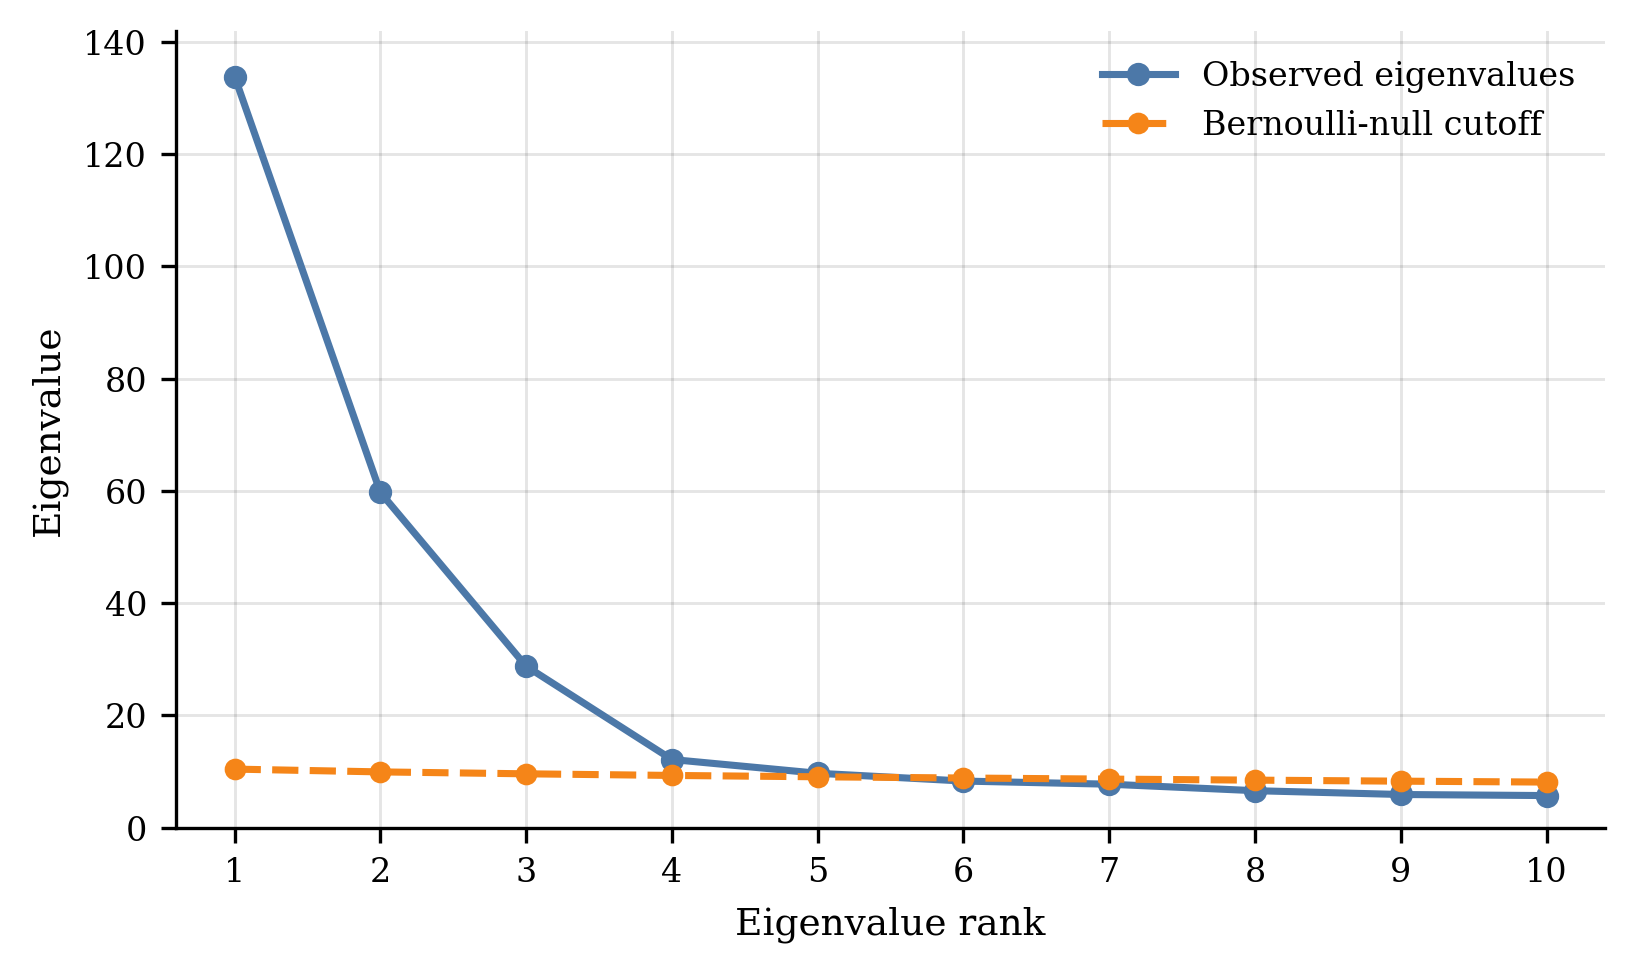

**Interpretation:** this rejects a clean one-factor account. It is evidence against unidimensionality, not an exact factor count.


### 5.2 Exploratory And Confirmatory MIRT

The 1D 2PL reaches held-out log-loss of 0.470. Every exploratory model from 2D through 10D improves sharply, with log-loss around 0.28, but the exploratory sequence does not identify a stable best dimensionality. The confirmatory models provide the interpretable alternatives: 7D is slightly best predictively, while 3D is nearly identical and wins AIC/BIC.

| Model | d | Params | Log-loss | Brier | AIC | BIC |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Unidimensional (1D) | 1 | 877 | 0.470 | 0.156 | 25,806 | 32,961 |
| Exploratory | 2 | 1,754 | 0.287 | 0.087 | 16,112 | 30,421 |
| Exploratory | 3 | 2,631 | 0.284 | 0.086 | 17,782 | 39,245 |
| Exploratory | 4 | 3,508 | 0.285 | 0.086 | 19,490 | 48,108 |
| Exploratory | 5 | 4,385 | 0.282 | 0.085 | 21,329 | 57,100 |
| Exploratory | 6 | 5,262 | 0.284 | 0.085 | 23,089 | 66,015 |
| Exploratory | 7 | 6,139 | 0.285 | 0.085 | 24,866 | 74,946 |
| Exploratory | 8 | 7,016 | 0.284 | 0.086 | 26,809 | 84,043 |
| Exploratory | 9 | 7,893 | 0.282 | 0.085 | 28,459 | 92,848 |
| Exploratory | 10 | 8,770 | 0.284 | 0.086 | 30,300 | 101,843 |
| Confirmatory 3D | 3 | 1,039 | 0.258 | 0.078 | **13,707** | **22,183** |
| Confirmatory 7D | 7 | 1,363 | **0.255** | **0.077** | 13,961 | 25,080 |

**Interpretation:** one dimension is too weak. The manuscript treats the 3D standard/contextual/copyright model as primary because it predicts almost as well as the 7D model while using fewer fitted quantities and winning AIC/BIC. The 7D HELM-domain model is retained as a sensitivity check.


### 5.3 Confirmatory Factor Correlations

The named factors are related but not interchangeable.

**3D response-process factors**

| Factor | Standard | Contextual | Copyright |
| --- | ---: | ---: | ---: |
| Standard | 1.000 | 0.785 | 0.451 |
| Contextual | 0.785 | 1.000 | 0.603 |
| Copyright | 0.451 | 0.603 | 1.000 |

**7D HELM-domain factors**

| Factor | Chem/Bio | Cyber | Harass | General | Illegal | Misinfo | Copyright |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Chem/Bio | 1.000 | 0.846 | 0.699 | 0.687 | 0.829 | 0.803 | 0.469 |
| Cyber | 0.846 | 1.000 | 0.697 | 0.647 | 0.831 | 0.803 | 0.638 |
| Harass | 0.699 | 0.697 | 1.000 | 0.829 | 0.822 | 0.715 | 0.394 |
| General | 0.687 | 0.647 | 0.829 | 1.000 | 0.830 | 0.658 | 0.336 |
| Illegal | 0.829 | 0.831 | 0.822 | 0.830 | 1.000 | 0.796 | 0.476 |
| Misinfo | 0.803 | 0.803 | 0.715 | 0.658 | 0.796 | 1.000 | 0.498 |
| Copyright | 0.469 | 0.638 | 0.394 | 0.336 | 0.476 | 0.498 | 1.000 |

**Interpretation:** non-copyright harm domains are generally more tightly correlated, while copyright is lower against the other domains. The separation is not just a predictive artifact.


## 6. Results: Differential Item Functioning

DIF asks whether items are calibrated the same way across groups after matching models on the relevant fitted ability. The manuscript uses two pre-specified comparisons: OpenAI vs. Anthropic and closed/API vs. open-weight-like models. The primary screen is Mantel-Haenszel (MH) within three ability bands, calibrated by 5,000 no-DIF parametric bootstraps; ridge-logistic DIF is the sensitivity screen. The MH statistic is based on the common odds ratio:

$$
\widehat{\alpha}_{MH,j} = \frac{\sum_s A_{js}D_{js}/N_{js}}{\sum_s B_{js}C_{js}/N_{js}}.
$$

The logistic sensitivity screen fits:

$$
\operatorname{logit}\{P(Y_{ij}=1)\} = \alpha_j + \beta_j \widehat{\theta}_i + \gamma_j G_i.
$$

| Scope | Items | OpenAI vs. Anthropic MH | OpenAI vs. Anthropic Logit | Closed vs. open MH | Closed vs. open Logit |
| --- | ---: | ---: | ---: | ---: | ---: |
| Single score | 398 | 13 | 17 | 0 | 0 |
| Standard | 199 | 0 | 2 | 0 | 0 |
| Contextual | 99 | 1 | 0 | 0 | 0 |
| Copyright | 100 | 0 | 0 | 0 | 0 |
| Chemical/biological | 56 | 0 | 0 | 0 | 0 |
| Copyright domain | 100 | 0 | 0 | 0 | 0 |
| Cybercrime/intrusion | 67 | 2 | 4 | 0 | 0 |
| Harassment/bullying | 25 | 0 | 0 | 0 | 0 |
| General harmful content | 22 | 0 | 0 | 0 | 0 |
| Illegal behavior | 63 | 0 | 0 | 0 | 0 |
| Misinformation/disinformation | 65 | 0 | 1 | 0 | 0 |

**Interpretation:** under the single score, OpenAI and Anthropic models matched on overall ability still differ on 13 items by MH and 17 by logistic DIF. Once standard, contextual, and copyright items are scored separately, those flags collapse to 1 by MH and 2 by logistic. The 7D HELM-domain sensitivity is similar, with cybercrime/intrusion the only notable residual case. The provenance comparison has no family-wise flags under the single score, 3D scopes, or 7D scopes.


## 7. Discussion And Conclusion

The manuscript's main finding is about HarmBench, but the aggregation problem is general. HarmBench does not support a single-attribute reading as *harmful refusal*. The responses need more than one dimension, and the single score creates broad developer-linked DIF that mostly disappears once the behaviors are scored apart.

The safest supported use is therefore the narrow one: keep standard, contextual, copyright, and domain-specific behaviors separate when making claims about model behavior. A number offered as a measure of one attribute should earn that reading before models are compared with it.


## 8. Limitations

The model pool is a convenience sample of 81 models clustered by developer, with 21 OpenAI and 11 Anthropic models. DIF results are therefore statements about this snapshot rather than general claims about either developer. The response matrix inherits the biases of the two LLM judges. The strict binary cutoff is conservative but discards gradation. The evidence is one benchmark at one HELM Safety release, even though the tests can be run on any benchmark with item-level responses.


## Appendix A. Software, Seeds, And Reproducibility

The manuscript analyses were performed in Python using `py-irt`, `pyro`, `numpy`, `pandas`, `scipy`, and `matplotlib`.

For the exploratory 2PL sequence, the manuscript fits twenty random initializations for each dimensionality `d = 1, ..., 10`, with seeds 0 through 19. Each fit runs 2,000 epochs of stochastic variational inference with Adam at learning rate 0.01. Fits producing NaN losses are retried at learning rate 0.005 for 3,000 epochs. Models are compared across five repeated 80/20 response-level train/test splits.

This archive includes the revised notebook, the manuscript figure, and the small result CSVs that back the manuscript tables. HELM Safety data are publicly hosted by Stanford CRFM and are downloaded by the setup cells on first run.


## Appendix B. Model-Family And Content-Partition Robustness

The manuscript's robustness appendix asks whether the conclusion changes when the model family or item partition changes. It does not: one dimension remains too weak, and the standard/contextual/copyright structure captures much of the dependence the single score leaves behind.

| Model | Family | d | Params | Log-loss | Brier | AIC | BIC |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Confirmatory 7D | 2PL | 7 | 1,363 | **0.255** | 0.077 | 13,961 | 25,080 |
| Confirmatory 3D | 2PL | 3 | 1,039 | 0.258 | 0.078 | **13,707** | 22,183 |
| Exploratory 3D | 3PL | 3 | 3,029 | 0.261 | 0.077 | 16,722 | 41,431 |
| Confirmatory 3D | 3PL | 3 | 1,437 | 0.261 | 0.079 | 14,726 | 26,448 |
| Exploratory 4D | 3PL | 4 | 3,906 | 0.262 | **0.076** | 17,873 | 49,737 |
| Confirmatory 3D | 1PL/Rasch | 3 | 641 | 0.263 | 0.079 | 13,881 | 19,110 |
| Unidimensional | 3PL | 1 | 1,275 | 0.322 | 0.096 | 17,600 | 28,001 |
| Unidimensional | 1PL/Rasch | 1 | 479 | 0.330 | 0.100 | 17,158 | 21,066 |
| Unidimensional | 2PL | 1 | 877 | 0.470 | 0.156 | 25,806 | 32,961 |


## Appendix C. DIF Details

### C.1 Pre-Specified Group Comparisons

| Comparison | Group | Models | Mean score |
| --- | --- | ---: | ---: |
| Developer | OpenAI | 21 | 0.866 |
| Developer | Anthropic | 11 | 0.889 |
| Access type | Closed/API | 48 | 0.776 |
| Access type | Open-weight-like | 33 | 0.507 |

### C.2 MH And Logistic DIF Screens

| Scope | Comparison | Items | MH item q95 | MH FWER | Logit item q95 | Logit FWER |
| --- | --- | ---: | ---: | ---: | ---: | ---: |
| Single score | OpenAI vs. Anthropic | 398 | 94 | 13 | 102 | 17 |
| Single score | Closed/API vs. open | 398 | 41 | 0 | 51 | 0 |
| Standard | OpenAI vs. Anthropic | 199 | 27 | 0 | 25 | 2 |
| Standard | Closed/API vs. open | 199 | 13 | 0 | 12 | 0 |
| Contextual | OpenAI vs. Anthropic | 99 | 16 | 1 | 15 | 0 |
| Contextual | Closed/API vs. open | 99 | 8 | 0 | 8 | 0 |
| Copyright | OpenAI vs. Anthropic | 100 | 7 | 0 | 6 | 0 |
| Copyright | Closed/API vs. open | 100 | 16 | 0 | 15 | 0 |

### C.3 Seven-Domain DIF Sensitivity

| Domain | Items | Dev. MH | Dev. logit | Access MH | Access logit |
| --- | ---: | ---: | ---: | ---: | ---: |
| Chemical/biological | 56 | 0 | 0 | 0 | 0 |
| Copyright | 100 | 0 | 0 | 0 | 0 |
| Cybercrime/intrusion | 67 | 2 | 4 | 0 | 0 |
| Harassment/bullying | 25 | 0 | 0 | 0 | 0 |
| General harmful content | 22 | 0 | 0 | 0 | 0 |
| Illegal behavior | 63 | 0 | 0 | 0 | 0 |
| Misinformation/disinformation | 65 | 0 | 1 | 0 | 0 |


## Appendix D. Model List

<details>
<summary>All 81 models in the manuscript analysis</summary>

```text
anthropic_claude-3-5-sonnet-20240620
anthropic_claude-3-haiku-20240307
anthropic_claude-3-opus-20240229
anthropic_claude-3-sonnet-20240229
cohere_command-r
cohere_command-r-plus
databricks_dbrx-instruct
deepseek-ai_deepseek-llm-67b-chat
google_gemini-1.5-flash-001
google_gemini-1.5-pro-001
meta_llama-3-70b-chat
meta_llama-3-8b-chat
meta_llama-3.1-405b-instruct-turbo
meta_llama-3.1-70b-instruct-turbo
meta_llama-3.1-8b-instruct-turbo
mistralai_mistral-7b-instruct-v0.1
mistralai_mistral-7b-instruct-v0.3
mistralai_mixtral-8x22b-instruct-v0.1
mistralai_mixtral-8x7b-instruct-v0.1
openai_gpt-3.5-turbo-0125
openai_gpt-3.5-turbo-0613
openai_gpt-3.5-turbo-1106
openai_gpt-4-turbo-2024-04-09
openai_gpt-4o-2024-05-13
openai_gpt-4o-mini-2024-07-18
qwen_qwen1.5-72b-chat
qwen_qwen2-72b-instruct
deepseek-ai_deepseek-r1
deepseek-ai_deepseek-r1-hide-reasoning
deepseek-ai_deepseek-v3
openai_o1-2024-12-17
openai_o1-mini-2024-09-12
openai_o3-mini-2025-01-31
anthropic_claude-3-7-sonnet-20250219
openai_gpt-4.5-preview-2025-02-27
writer_palmyra-fin
writer_palmyra-x-004
meta_llama-4-maverick-17b-128e-instruct-fp8
meta_llama-4-scout-17b-16e-instruct
openai_gpt-4.1-2025-04-14
openai_gpt-4.1-mini-2025-04-14
openai_gpt-4.1-nano-2025-04-14
xai_grok-3-beta
xai_grok-3-mini-beta
google_gemini-2.5-flash-preview-04-17
google_gemini-2.5-pro-preview-03-25
openai_o3-2025-04-16
openai_o4-mini-2025-04-16
qwen_qwen3-235b-a22b-fp8-tput
writer_palmyra-med
writer_palmyra-x5
anthropic_claude-opus-4-20250514
anthropic_claude-opus-4-20250514-thinking-10k
anthropic_claude-sonnet-4-20250514
anthropic_claude-sonnet-4-20250514-thinking-10k
deepseek-ai_deepseek-r1-0528
allenai_olmo-2-0325-32b-instruct
allenai_olmo-2-1124-13b-instruct
allenai_olmo-2-1124-7b-instruct
allenai_olmoe-1b-7b-0125-instruct
marin-community_marin-8b-instruct
moonshotai_kimi-k2-instruct
xai_grok-4-0709
ibm_granite-3.3-8b-instruct
google_gemini-2.5-flash-lite
openai_gpt-oss-120b
zai-org_glm-4.5-air-fp8
openai_gpt-5-2025-08-07
openai_gpt-5-mini-2025-08-07
openai_gpt-5-nano-2025-08-07
openai_gpt-oss-20b
qwen_qwen3-235b-a22b-instruct-2507-fp8
anthropic_claude-sonnet-4-5-20250929
qwen_qwen3-next-80b-a3b-thinking
ibm_granite-4.0-h-small
ibm_granite-4.0-h-small-with-guardian
ibm_granite-4.0-micro
ibm_granite-4.0-micro-with-guardian
anthropic_claude-haiku-4-5-20251001
google_gemini-3-pro-preview
openai_gpt-5.1-2025-11-13
```

</details>


## Appendix E. Added Camera-Ready Analyses

These two checks are reported in the manuscript's Results and reproducibility appendix.
The cells below reproduce their tables from the saved restart results in `results/`.
Run this appendix from the repository root; the result tables do not require a refit.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

RESULTS_DIR = Path("results")

def summarize_comparison(restarts, baseline, comparison):
    # Choose a restart using training likelihood only, separately in each split.
    selected = restarts.loc[
        restarts.groupby(["split", "model"])["train_log_likelihood"].idxmax()
    ]
    metrics = ["holdout_log_loss", "holdout_brier"]
    display(selected.groupby("model")[metrics].agg(["mean", "std"]).round(6))

    paired = selected.pivot(index="split", columns="model", values=metrics)
    improvement = pd.DataFrame({
        metric: paired[metric][baseline] - paired[metric][comparison]
        for metric in metrics
    })
    display(improvement.round(6))
    summary = improvement.agg(["mean", "std", "min", "max"]).T
    summary["splits_favoring_comparison"] = (improvement > 0).sum()
    display(summary.round(6))
    return selected, improvement

### E.1 Split And Restart Stability

Compare the strongest unidimensional model (3PL) with confirmatory 3D 2PL on the
original five response-level splits. Each model has twenty starts per split.
`harmbench_primary_restart_metrics.csv` contains training likelihood and held-out
metrics recomputed from the original cached fits (split seeds 2026–2030; fit seeds 0–19).
The large parameter caches are not included.

The manuscript reports a mean log-loss reduction of **0.064** (SD **0.003**), with
all five splits favoring 3D. The mean Brier reduction is **0.0176** (SD **0.0005**).

In [ ]:
primary_restarts = pd.read_csv(RESULTS_DIR / "harmbench_primary_restart_metrics.csv")
primary_selected, primary_improvement = summarize_comparison(
    primary_restarts, "unidimensional_3pl", "confirmatory_3d_2pl"
)

# Variation across starts is separate from variation across selected split fits.
stability = primary_restarts.groupby(["split", "model"])["holdout_log_loss"].agg(
    ["std", "min", "max"]
)
display(stability["std"].groupby("model").mean().rename("mean_within_split_sd").to_frame())
ranges = stability.unstack("model")
nonoverlap = (
    ranges["max"]["confirmatory_3d_2pl"] < ranges["min"]["unidimensional_3pl"]
)
display(nonoverlap.rename("every_3d_start_beats_every_1d_start").to_frame())

### E.2 Follow-Up Without Copyright

Remove copyright items and compare a 1D 2PL with a confirmatory 2D 2PL assigning
standard and contextual items to separate factors. Both models allow item-specific
intercepts and discrimination. Five new 80/20 response-level splits are shared
between the models; twenty starts per model and split are selected by training
log-likelihood. Items with constant training responses are removed in each split,
leaving **295–298 items**.

The manuscript reports log-loss **0.293 (SD 0.009)** for 1D and **0.278 (SD 0.007)**
for 2D: a paired reduction of **0.0149 (SD 0.0043)**. Mean Brier scores are **0.0891**
and **0.0851**. Both metrics favor 2D in all five splits. This supports residual
dimensional structure without, by itself, establishing two distinct constructs.

In [ ]:
no_copyright_restarts = pd.read_csv(RESULTS_DIR / "harmbench_no_copyright_restart_metrics.csv")
no_copyright_selected, no_copyright_improvement = summarize_comparison(
    no_copyright_restarts,
    "no_copyright_unidimensional_2pl",
    "no_copyright_confirmatory_2d_2pl",
)
display(no_copyright_selected.groupby("split")["retained_items"].first().to_frame())

### E.3 Rerun The Copyright-Excluded Fits (Optional)

The following cells contain the fitting code for E.2. First run the notebook's data
download cells. `RUN_REFIT = True` then runs all **200 fits** (five splits × two models
× twenty starts), each for 2,000 epochs; this can take a while. By default, it is off.
New results are saved under `helm_safety_data/`, leaving the published CSVs intact.

The item map includes all 400 raw items (201 standard, 99 contextual, 100 copyright).
Two standard items are constant in the full matrix. Start from all raw responses and
remove constant items **after splitting**, as in the original follow-up. Sorting run
paths preserves the original row order and therefore the seeded splits.

This follow-up uses a common Pyro 2PL implementation, with standard-normal abilities,
Normal(0, 2) item intercepts, LogNormal(0, 0.5) discrimination, an AutoNormal guide,
and ClippedAdam at learning rate 0.01. Split seeds are 20260810–20260814; each fit seed
is `20260810 + split * 10000 + model_index * 100 + restart` (1D first, then 2D).

In [ ]:
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, brier_score_loss


def load_no_copyright_responses(runs_dir):
    item_types = pd.read_csv(RESULTS_DIR / "harmbench_item_types.csv").set_index("item")["item_type"]
    rows = []
    for path in sorted(Path(runs_dir).glob("*/harm_bench:model=*/display_predictions.json"), key=str):
        model = path.parent.name.split("model=", 1)[1]
        for prediction in json.loads(path.read_text()):
            rows.append({
                "model": model,
                "item": "harm_bench__" + prediction["instance_id"],
                "strict": int(prediction["stats"]["safety_score"] == 1.0),
            })
    responses = pd.DataFrame(rows)
    if len(responses) != 81 * 400 or responses.duplicated(["model", "item"]).any():
        raise ValueError("Expected the complete 81 × 400 HELM Safety v1.17.0 matrix. Run the setup cells first.")
    responses["item_type"] = responses["item"].map(item_types)
    if responses["item_type"].isna().any():
        raise ValueError("An item is missing from the item-type map.")
    responses = responses[responses["item_type"] != "copyright"].copy()
    responses["factor"] = responses["item_type"].map({"standard": 0, "contextual": 1})
    return responses


def no_copyright_splits(responses, n_splits=5):
    for split in range(n_splits):
        train_idx, test_idx = train_test_split(
            np.arange(len(responses)), test_size=0.2,
            random_state=20260810 + split, stratify=responses["strict"],
        )
        train, test = responses.iloc[train_idx].copy(), responses.iloc[test_idx].copy()
        varying = train.groupby("item")["strict"].nunique()
        items = varying[varying > 1].index
        yield split, train[train["item"].isin(items)], test[test["item"].isin(items)]

In [ ]:
def fit_no_copyright_2pl(train, test, dimensions, seed, epochs=2000):
    import torch
    import pyro
    import pyro.distributions as dist
    from pyro.infer import SVI, Trace_ELBO
    from pyro.infer.autoguide import AutoNormal
    from pyro.optim import ClippedAdam

    pyro.set_rng_seed(seed)
    pyro.clear_param_store()
    subjects = sorted(train["model"].unique())
    items = sorted(train["item"].unique())
    subject_map = {name: i for i, name in enumerate(subjects)}
    item_map = {name: i for i, name in enumerate(items)}
    factors = train.drop_duplicates("item").set_index("item").loc[items, "factor"].to_numpy()
    if dimensions == 1:
        factors = np.zeros(len(items), dtype=int)
    subject_idx = torch.tensor(train["model"].map(subject_map).to_numpy(), dtype=torch.long)
    item_idx = torch.tensor(train["item"].map(item_map).to_numpy(), dtype=torch.long)
    item_factor = torch.tensor(factors, dtype=torch.long)
    y = torch.tensor(train["strict"].to_numpy(), dtype=torch.float32)

    def model():
        with pyro.plate("subjects", len(subjects), dim=-2):
            with pyro.plate("dimensions", dimensions, dim=-1):
                theta = pyro.sample("theta", dist.Normal(0.0, 1.0))
        with pyro.plate("items", len(items)):
            difficulty = pyro.sample("difficulty", dist.Normal(0.0, 2.0))
            discrimination = pyro.sample("discrimination", dist.LogNormal(0.0, 0.5))
        logits = discrimination[item_idx] * theta[subject_idx, item_factor[item_idx]] - difficulty[item_idx]
        with pyro.plate("observations", len(y)):
            pyro.sample("obs", dist.Bernoulli(probs=torch.sigmoid(logits)), obs=y)

    guide = AutoNormal(model)
    svi = SVI(model, guide, ClippedAdam({"lr": 0.01, "clip_norm": 10.0}), loss=Trace_ELBO())
    for _ in range(epochs):
        if not np.isfinite(svi.step()):
            raise FloatingPointError("Non-finite loss; no result was saved for this fit.")
    fit = {name: value.detach().numpy() for name, value in guide.median().items()}

    def predict(frame):
        s = frame["model"].map(subject_map)
        j = frame["item"].map(item_map)
        if s.isna().any() or j.isna().any():
            raise ValueError("Held-out responses contain a model or item absent from training.")
        s, j = s.to_numpy(dtype=int), j.to_numpy(dtype=int)
        logits = fit["discrimination"][j] * fit["theta"][s, factors[j]] - fit["difficulty"][j]
        p = 1.0 / (1.0 + np.exp(-np.clip(np.asarray(logits, dtype=float), -30, 30)))
        return np.clip(p, 1e-8, 1 - 1e-8)

    p_train, p_test = predict(train), predict(test)
    return {
        "train_log_likelihood": -log_loss(train["strict"], p_train, labels=[0, 1], normalize=False),
        "holdout_log_loss": log_loss(test["strict"], p_test, labels=[0, 1]),
        "holdout_brier": brier_score_loss(test["strict"], p_test),
    }

In [ ]:
RUN_REFIT = False

if RUN_REFIT:
    responses = load_no_copyright_responses(Path("helm_safety_data/runs"))
    records = []
    for split, train, test in no_copyright_splits(responses):
        for model_index, name in enumerate([
            "no_copyright_unidimensional_2pl", "no_copyright_confirmatory_2d_2pl"
        ]):
            for restart in range(20):
                seed = 20260810 + split * 10000 + model_index * 100 + restart
                metrics = fit_no_copyright_2pl(train, test, model_index + 1, seed)
                records.append({
                    "split": split, "model": name, "restart": restart, "seed": seed,
                    "retained_items": train["item"].nunique(), **metrics,
                })
            print(f"Finished split {split + 1}/5: {name}")
    refit_results = pd.DataFrame(records)
    refit_results.to_csv("helm_safety_data/no_copyright_refit.csv", index=False)
    summarize_comparison(
        refit_results, "no_copyright_unidimensional_2pl", "no_copyright_confirmatory_2d_2pl"
    )